# AI/ML Task 2 — Feature Engineering, Model Optimization & Performance Comparison

**Goal:** Improve on the Task 1 baseline (Linear Regression, R² = 0.576) by applying
feature scaling, training multiple regression models, and selecting the
best-performing one using proper evaluation metrics.

## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")

## Step 2: Load the Dataset

Same dataset as Task 1 — the California Housing dataset. Target variable is
the median house value (`MedHouseVal`), and there are 8 numeric input features.

In [2]:
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("MedHouseVal")], axis=1)

print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Step 3: Separate Features and Target Variable

In [3]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

## Step 4: Train–Test Split

**Important:** the split happens *before* scaling. If you scale the whole
dataset first and split afterward, information from the test set leaks into
the scaler's mean/std, which quietly inflates your test performance. Splitting
first keeps the test set genuinely unseen.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (16512, 8) Test: (4128, 8)


## Step 5: Feature Scaling (Critical Step)

Features live on very different numeric ranges (e.g. `Population` in the
thousands vs `AveRooms` in single digits). Without scaling, models like Ridge
Regression treat large-magnitude features as more "important" than they
really are. `StandardScaler` transforms every feature to mean 0, std 1.

The scaler is **fit only on the training data**, then used to transform both
train and test — this avoids leaking test-set statistics into the scaling.

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 6: Train Multiple Models

Three models, each with a different role:

- **Linear Regression** — the baseline (same algorithm as Task 1)
- **Ridge Regression** — linear regression with an L2 penalty that shrinks
  coefficients, helping reduce overfitting
- **Decision Tree (max_depth=5)** — captures non-linear relationships that a
  linear model can't

In [6]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)
}

## Step 7: Model Evaluation and Comparison

Each model is trained on the scaled training data and evaluated on the
scaled test data using RMSE and R². Train-set R² is also recorded, so a
large gap between train and test R² can flag overfitting.

- **Lower RMSE** → better prediction accuracy
- **Higher R²** → more variance explained

In [15]:
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    train_preds = model.predict(X_train_scaled)
    test_preds = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    r2_test = r2_score(y_test, test_preds)
    r2_train = r2_score(y_train, train_preds)

    results[name] = {
        "Train R2": r2_train,
        "Test R2": r2_test,
        "RMSE": rmse
    }

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values("RMSE")
results_df

,Train R2,Test R2,RMSE
Decision Tree,0.637679,0.599732,0.724234
Ridge Regression,0.612551,0.575816,0.745557
Linear Regression,0.612551,0.575788,0.745581


## Visualizing Model Performance

Let's visualize the `results_df` to compare the performance metrics (Train R², Test R², and RMSE) across the different models.

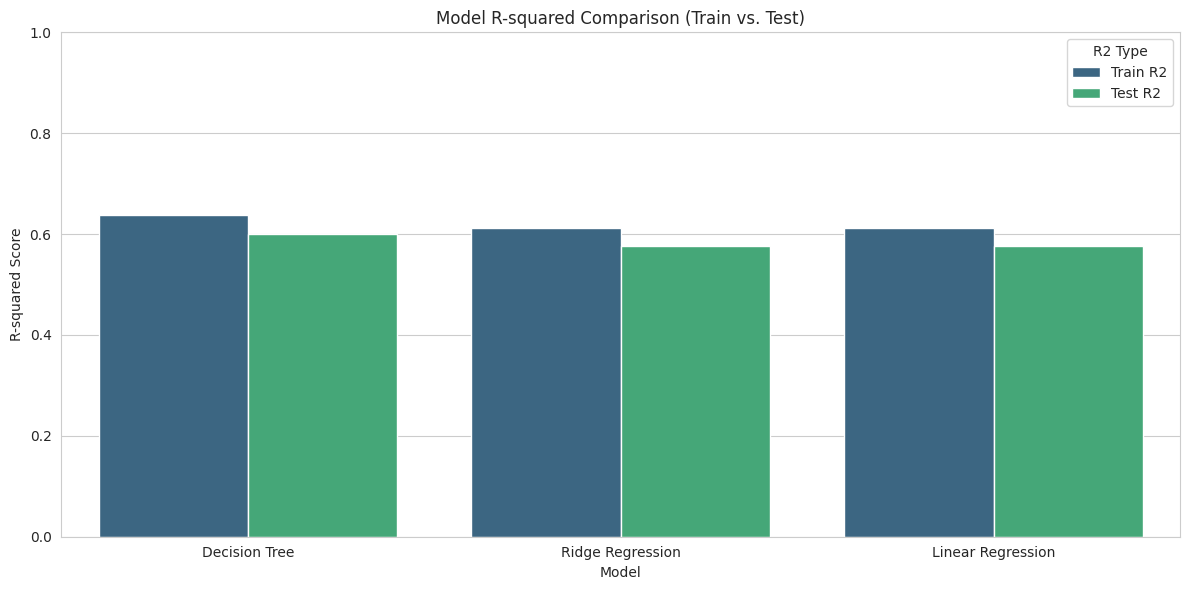

/tmp/ipykernel_3591/2020300509.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['RMSE'], palette='magma')


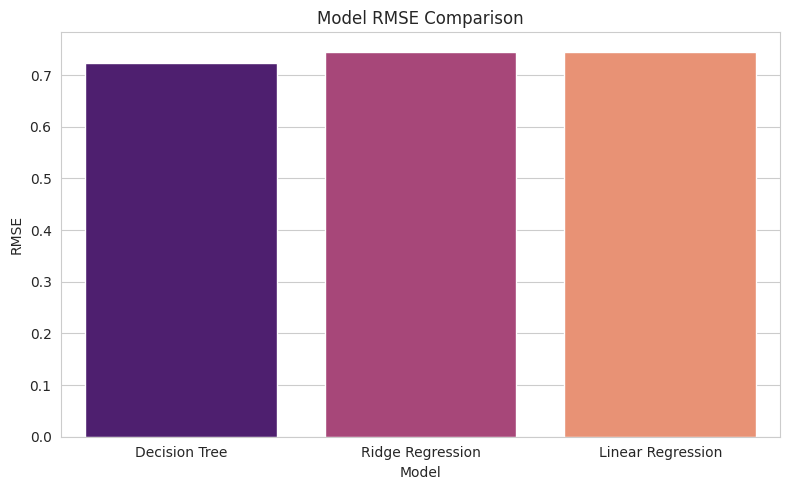

In [16]:
plt.figure(figsize=(12, 6))

# Prepare data for R2 plot
r2_df = results_df[['Train R2', 'Test R2']].reset_index()
r2_df_melted = r2_df.melt(id_vars='index', var_name='Metric', value_name='R2 Score')

sns.barplot(x='index', y='R2 Score', hue='Metric', data=r2_df_melted, palette='viridis')
plt.title('Model R-squared Comparison (Train vs. Test)')
plt.xlabel('Model')
plt.ylabel('R-squared Score')
plt.ylim(0, 1) # R2 score ranges from 0 to 1
plt.legend(title='R2 Type')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x=results_df.index, y=results_df['RMSE'], palette='magma')
plt.title('Model RMSE Comparison')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.tight_layout()
plt.show()

## Step 8: Select the Best Model

Instead of hardcoding a model, pick it programmatically from the results —
the model with the lowest test RMSE.

In [8]:
best_model_name = results_df["RMSE"].idxmin()
best_model = models[best_model_name]

print(f"Best model: {best_model_name}")
print(results_df.loc[best_model_name])

Best model: Decision Tree
Train R2    0.637679
Test R2     0.599732
RMSE        0.724234
Name: Decision Tree, dtype: float64


## Step 9: Visual Performance Validation — Actual vs Predicted

Points closer to the red diagonal line indicate more accurate predictions.

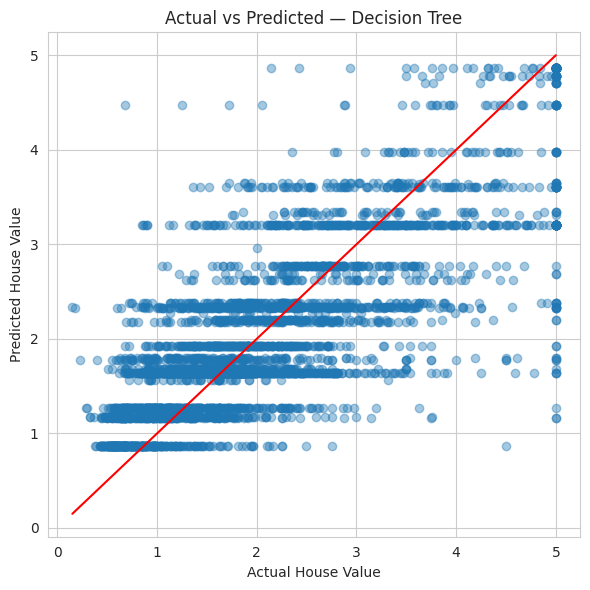

In [9]:
y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title(f"Actual vs Predicted — {best_model_name}")
plt.tight_layout()
plt.show()

## Step 10: Residuals Distribution
Shows whether prediction errors are centered around zero and roughly
symmetric, which indicates the model isn't systematically over- or
under-predicting.

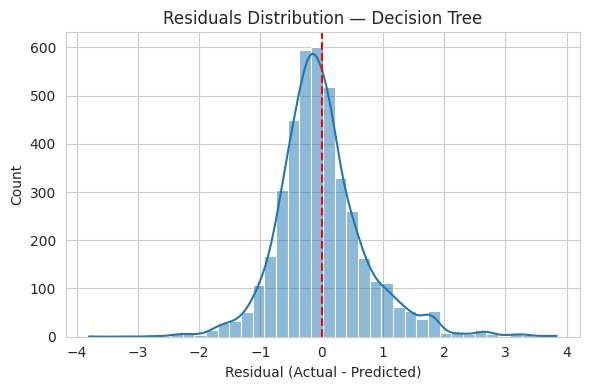

In [10]:
residuals = y_test - y_pred_best

plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True, bins=40)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Residual (Actual - Predicted)")
plt.title(f"Residuals Distribution — {best_model_name}")
plt.tight_layout()
plt.show()

## Step 11: Model Comparison Summary Table

In [11]:
print("Model Performance Comparison:\n")
print(results_df.round(4).to_string())

Model Performance Comparison:

                   Train R2  Test R2    RMSE
Decision Tree        0.6377   0.5997  0.7242
Ridge Regression     0.6126   0.5758  0.7456
Linear Regression    0.6126   0.5758  0.7456


## Step 12: Save the Best Model

In [12]:
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print(f"Saved '{best_model_name}' to best_model.pkl")

Saved 'Decision Tree' to best_model.pkl


## Conclusions

- Applying `StandardScaler` puts all features on a comparable scale, which
  matters for Ridge's penalty term (it has little effect on plain Linear
  Regression's predictions, and none on a Decision Tree, since trees are
  scale-invariant).
- Among Linear Regression, Ridge Regression, and a depth-5 Decision Tree,
  **[fill in: best_model_name]** achieved the lowest test RMSE and highest
  test R².
- Comparing train R² vs test R² shows [fill in: whether any model overfit —
  a much higher train score than test score is the signal].
- Next steps for further improvement: try ensemble models (Random Forest,
  Gradient Boosting), tune Ridge's `alpha` and the tree's `max_depth` via
  cross-validation, and engineer features such as rooms-per-household.